# Importacion de librerias

In [51]:
from wget import download
from os import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Descarga de datos

In [52]:
datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")

/tmp/ipykernel_36378/175755440.py:1: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  datos_arbolado= pd.read_csv("../data/arbolado-publico-lineal-2017-2018.csv")


# Apertura de datos

In [53]:
datos_arbolado.head()

,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0


In [54]:
datos_arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

In [55]:
datos_arbolado.describe()

,long,lat,comuna,diametro_altura_pecho,altura_arbol
count,354838.000000,354838.000000,370180.000000,369894.000000,365858.000000
mean,-58.458791,-34.612473,9.143735,31.986864,9.036132
std,0.041514,0.033695,3.876242,21.267623,4.894625
min,-58.530458,-34.697333,1.000000,0.000000,1.000000
25%,-58.491269,-34.637834,6.000000,17.000000,6.000000
50%,-58.465865,-34.615023,10.000000,29.000000,8.000000
75%,-58.428583,-34.586580,12.000000,43.000000,12.000000
max,-58.354003,-34.535972,15.000000,199.000000,40.000000


# Visualizacion de datos crudos

## Latitud y longitud expresadas en forma de mapa


### Imprimir scatter que representa el mapa de la ciudad en relacion a los arboles


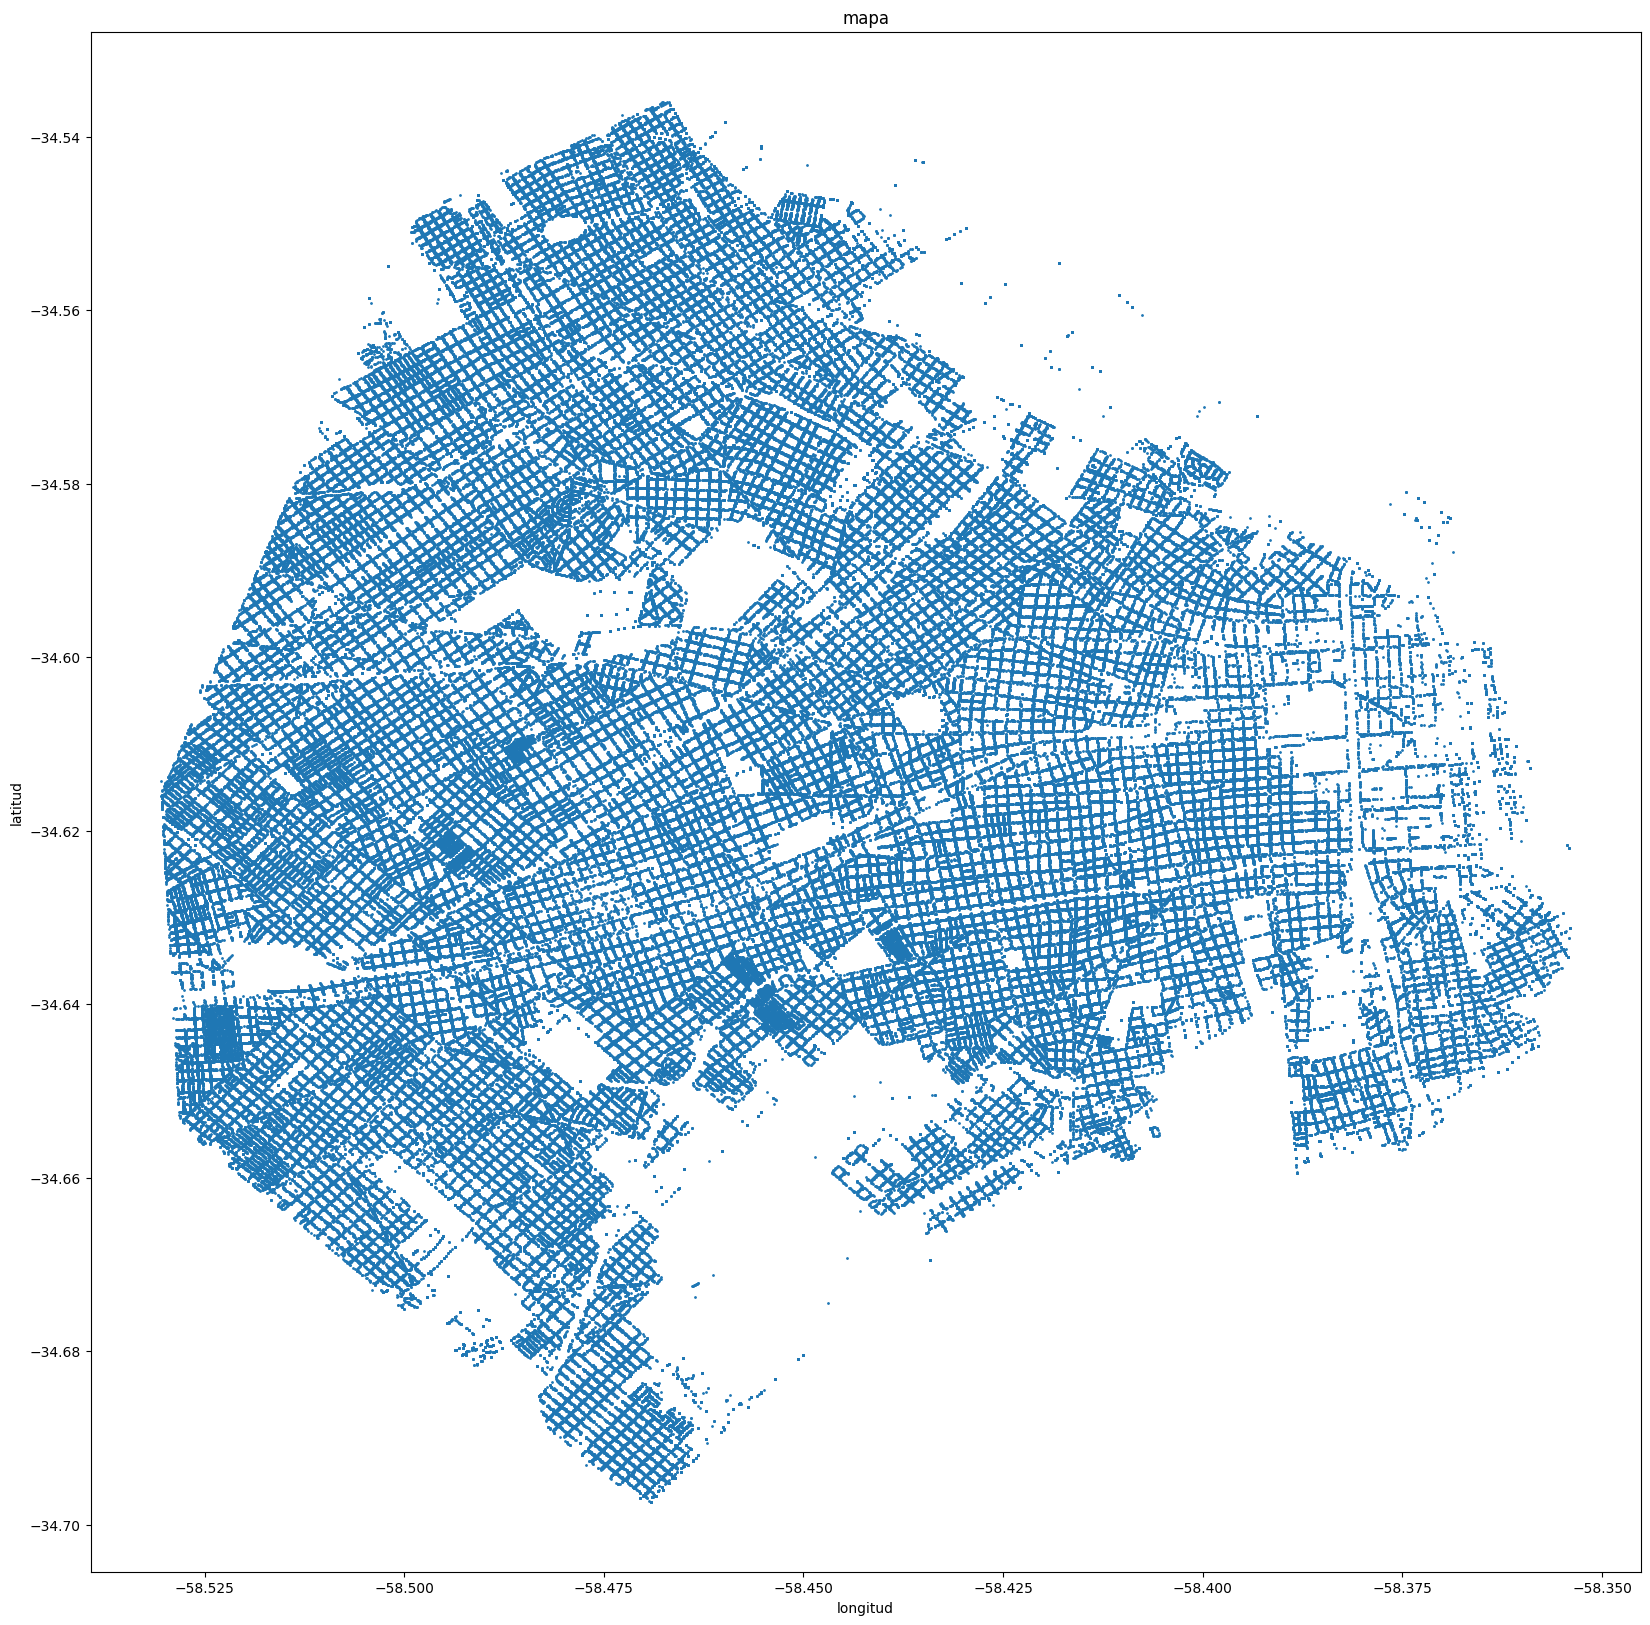

In [56]:
plt.figure(figsize=(20,20))
plt.scatter(datos_arbolado['long'], datos_arbolado['lat'], s=1)
plt.xlabel("longitud")
plt.ylabel("latitud")
plt.title("mapa")

plt.show()

## nro_registro
Representa un identificador unico para cada arbol

In [57]:
datos_arbolado['nro_registro']

0          26779
1          30887
2          30904
3          31336
4          31337
           ...  
370175    546140
370176    546141
370177    546142
370178    546143
370179    546144
Name: nro_registro, Length: 370180, dtype: object

In [58]:
datos_arbolado=datos_arbolado.drop('nro_registro',axis=1)

## tipo_actividad

### ¿Que representa el tipo de actividad?
analizar la variable, viendo que tipos de actividad hay y que significa cada una

In [59]:
datos_arbolado['tipo_activ'].value_counts()
datos_arbolado= datos_arbolado.drop('tipo_activ',axis=1)


Los tipos de actividad representan el tipo de relevamiento o censo que el arbol forma parte del arbolado publico lineal.
Los tipos son lineal y de calle. que representan lo mismo. por lo tanto el conjunto de datos representa arboles de alumbrado publico, es decir de la vereda.


## Comunas


### Como se diferencian las comunas?

In [60]:
datos_arbolado['comuna'].value_counts()

comuna
12    38818
11    37340
9     36405
10    33421
4     32346
15    29587
13    28287
7     25608
14    22417
8     21978
6     15591
5     15224
3     13320
1     12723
2      7115
Name: count, dtype: int64

/tmp/ipykernel_36378/3762084320.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


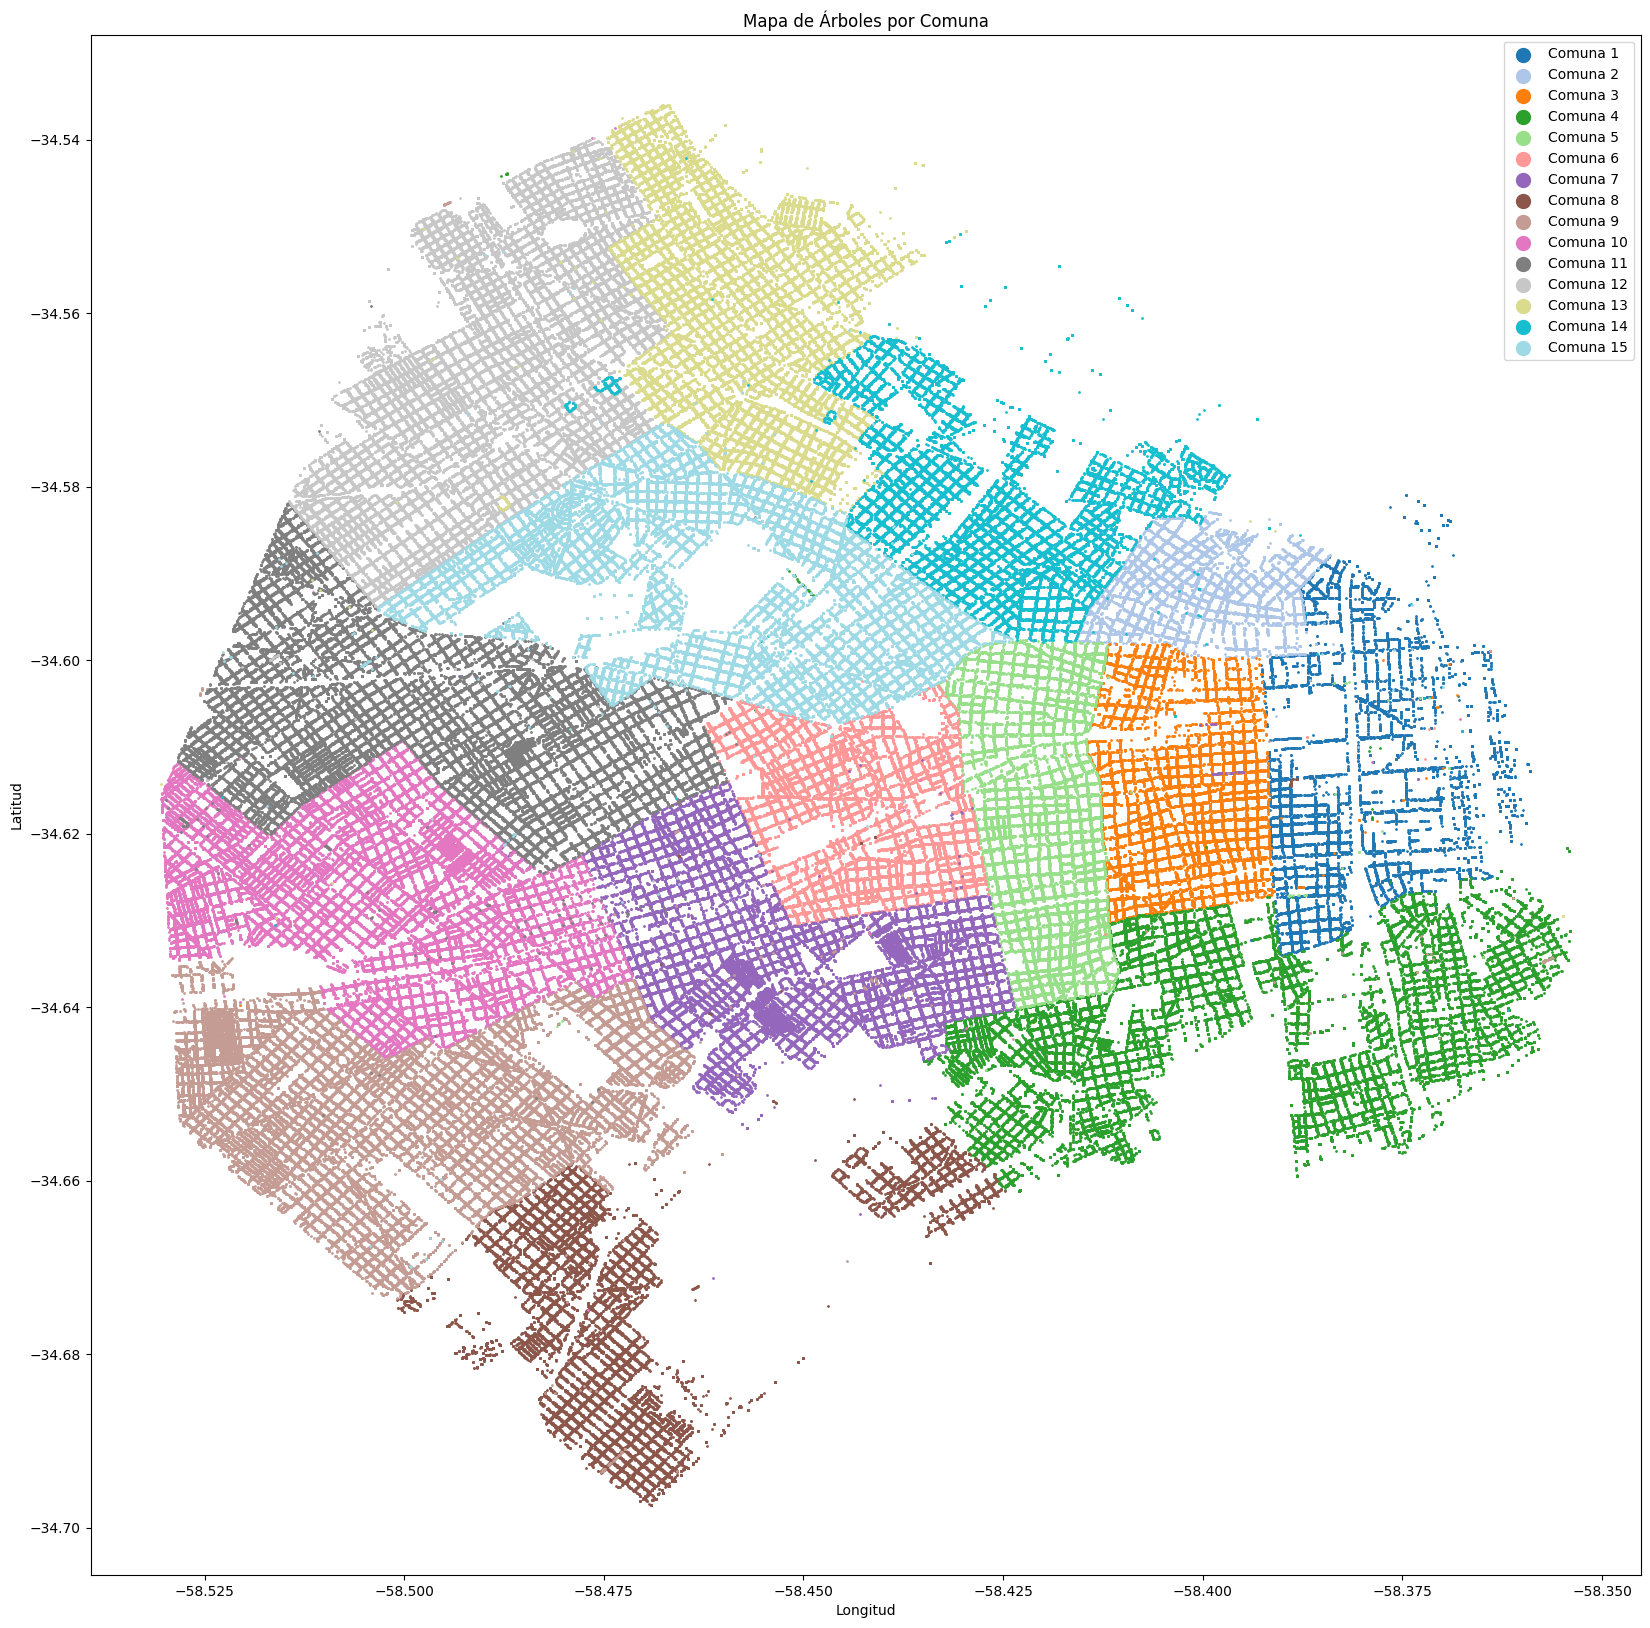

In [61]:
plt.figure(figsize=(20, 20))
categorias = sorted(datos_arbolado['comuna'].unique())
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, comuna in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['comuna'] == comuna]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=1,
        color=colores(i),
        label=f'Comuna {int(comuna)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por Comuna")
plt.legend(markerscale=10)
plt.show()

## Manzanas

### Como se diferencia las manzanas?

In [62]:
datos_arbolado['manzana'].value_counts()

manzana
568      1102
16        462
948       455
467       421
874       412
         ... 
566 c       1
47p         1
980 i       1
23y         1
126 b       1
Name: count, Length: 1843, dtype: int64

## Calle_nombre

In [63]:
datos_arbolado['calle_nombre'].value_counts()

calle_nombre
Del Libertador, Av           1267
Alberdi Juan Bautista Av.    1153
Directorio Av.               1138
Rivadavia, Av                1133
Yerbal                       1128
                             ... 
Pérez                           1
Paracas                         1
Fenando de Montalvo             1
Jofre                           1
Dorrego                         1
Name: count, Length: 2334, dtype: int64

## calle_altura

In [64]:
datos_arbolado['calle_altura'].value_counts()

calle_altura
1400.0        5483
1200.0        5275
1500.0        5225
1100.0        5180
1300.0        5148
              ... 
39001717.0       1
30000.0          1
2241.0           1
2215.0           1
410011.0         1
Name: count, Length: 1828, dtype: int64

## Direccion_normalizada


In [65]:
datos_arbolado['direccion_normalizada'].value_counts()


direccion_normalizada
ESPAÑA AV.                                351
OBLIGADO RAFAEL, AV.COSTANERA             307
DORREGO AV.                               255
ALSINA, VALENTIN AV.                      216
DEL LIBERTADOR AV.                        185
                                         ... 
GARCIA DE COSSIO 6044                       1
CASTRO, EMILIO AV. 7615                     1
PIERES 404                                  1
PALMAR 6689                                 1
GARCIA GRANDE DE ZEQUEIRA, SEVERO 5589      1
Name: count, Length: 248939, dtype: int64

In [66]:
datos_arbolado=datos_arbolado.drop('direccion_normalizada',axis=1)

## Ubicacion

In [67]:
for idx, val in datos_arbolado['ubicacion'].value_counts().items():
    print(idx, val)

Exacta 242660
LA 56069
LD 47636
LA1 2464
LD1 2107
En frente 910
LA2 845
LA 1 816
LD2 772
LD 1 638
LA3 469
LD3 410
En frente - Exacta 336
LA4 308
LD4 261
LA 2 252
LA5 242
LD 2 232
LA6 199
LD5 189
LA7 165
LA8 141
LD6 139
LA9 125
LA 3 123
LD7 118
LD 3 115
En frente - LA 112
En frente - LD 105
LD 4 103
LA10 102
LD8 92
LA 4 90
LA11 85
EX 83
LA12 76
LD9 73
LA13 66
LD 5 64
LA 5 62
LD10 58
LA14 56
LD 6 49
LA 6 49
LD11 48
LD12 43
LA15 43
LA 7 39
LA16 38
LD 7 38
LD 8 35
LD13 32
Ex 31
LA 8 29
LD14 29
LA17 28
Exacta  27
LA 9 25
LD 9 24
Enfrente Ext 23
LD 10 23
LA18 23
LD15 22
LA19 21
LA20 21
LD16 20
LA21 20
LD 11 20
LA22 20
LA 11 19
LA23 18
LA 10 18
LA25 16
LA24 16
Vereda 16
LD17 15
En frente -  Exacta 14
Exacto 14
LD18 14
LD20 13
LA27 13
LA26 13
LD22 12
LA28 12
LD19 12
LD 12 11
LD21 11
LD 14 11
la1 11
La1 10
LD23 10
LA 13 10
LA 12 10
LD 13 10
LA29 9
LD24 9
LD 1  8
la2 8
LA 14 8
LD25 8
LD 15 8
LA30 8
ld1 7
LD26 7
la3 7
LA33 6
LA31 6
LA32 6
LD27 6
LA 15 6
LA 16 6
lD1 6
Enfrente LD1 6
LD28 6
LD 19 5

In [68]:
datos_arbolado=datos_arbolado.drop('ubicacion',axis=1)

## Nombre_cientifico

In [69]:

dic= datos_arbolado['nombre_cientifico'].value_counts()>5000
print(dic)
nombres_cientificos= datos_arbolado[datos_arbolado['nombre_cientifico'].map(dic)]






nombre_cientifico
Fraxinus pennsylvanica     True
Platanus x acerifolia      True
Ficus benjamina            True
Tilia x moltkei            True
Melia azedarach            True
                          ...  
Prunus serrulata          False
Synadenium grantii        False
Sterculia monosperma      False
Ficus microcarpa          False
Maclura pomifera          False
Name: count, Length: 431, dtype: bool


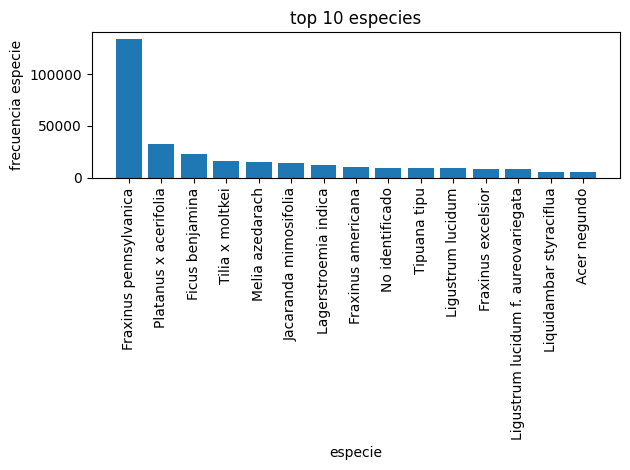

In [70]:


top10= datos_arbolado['nombre_cientifico'].value_counts().nlargest(15)
nombre= top10.index
conteo= top10.values

plt.Figure(figsize=(12,7))

plt.bar(nombre,conteo)
plt.title('top 10 especies')
plt.ylabel('frecuencia especie')
#plt.yscale('log')
plt.xlabel('especie')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [71]:
datos_arbolado[datos_arbolado['nombre_cientifico']=='No identificado']
datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')


/tmp/ipykernel_36378/665506149.py:2: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  datos_arbolado['nombre_cientifico']= datos_arbolado['nombre_cientifico'].replace('No identificado')


/tmp/ipykernel_36378/93965224.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))


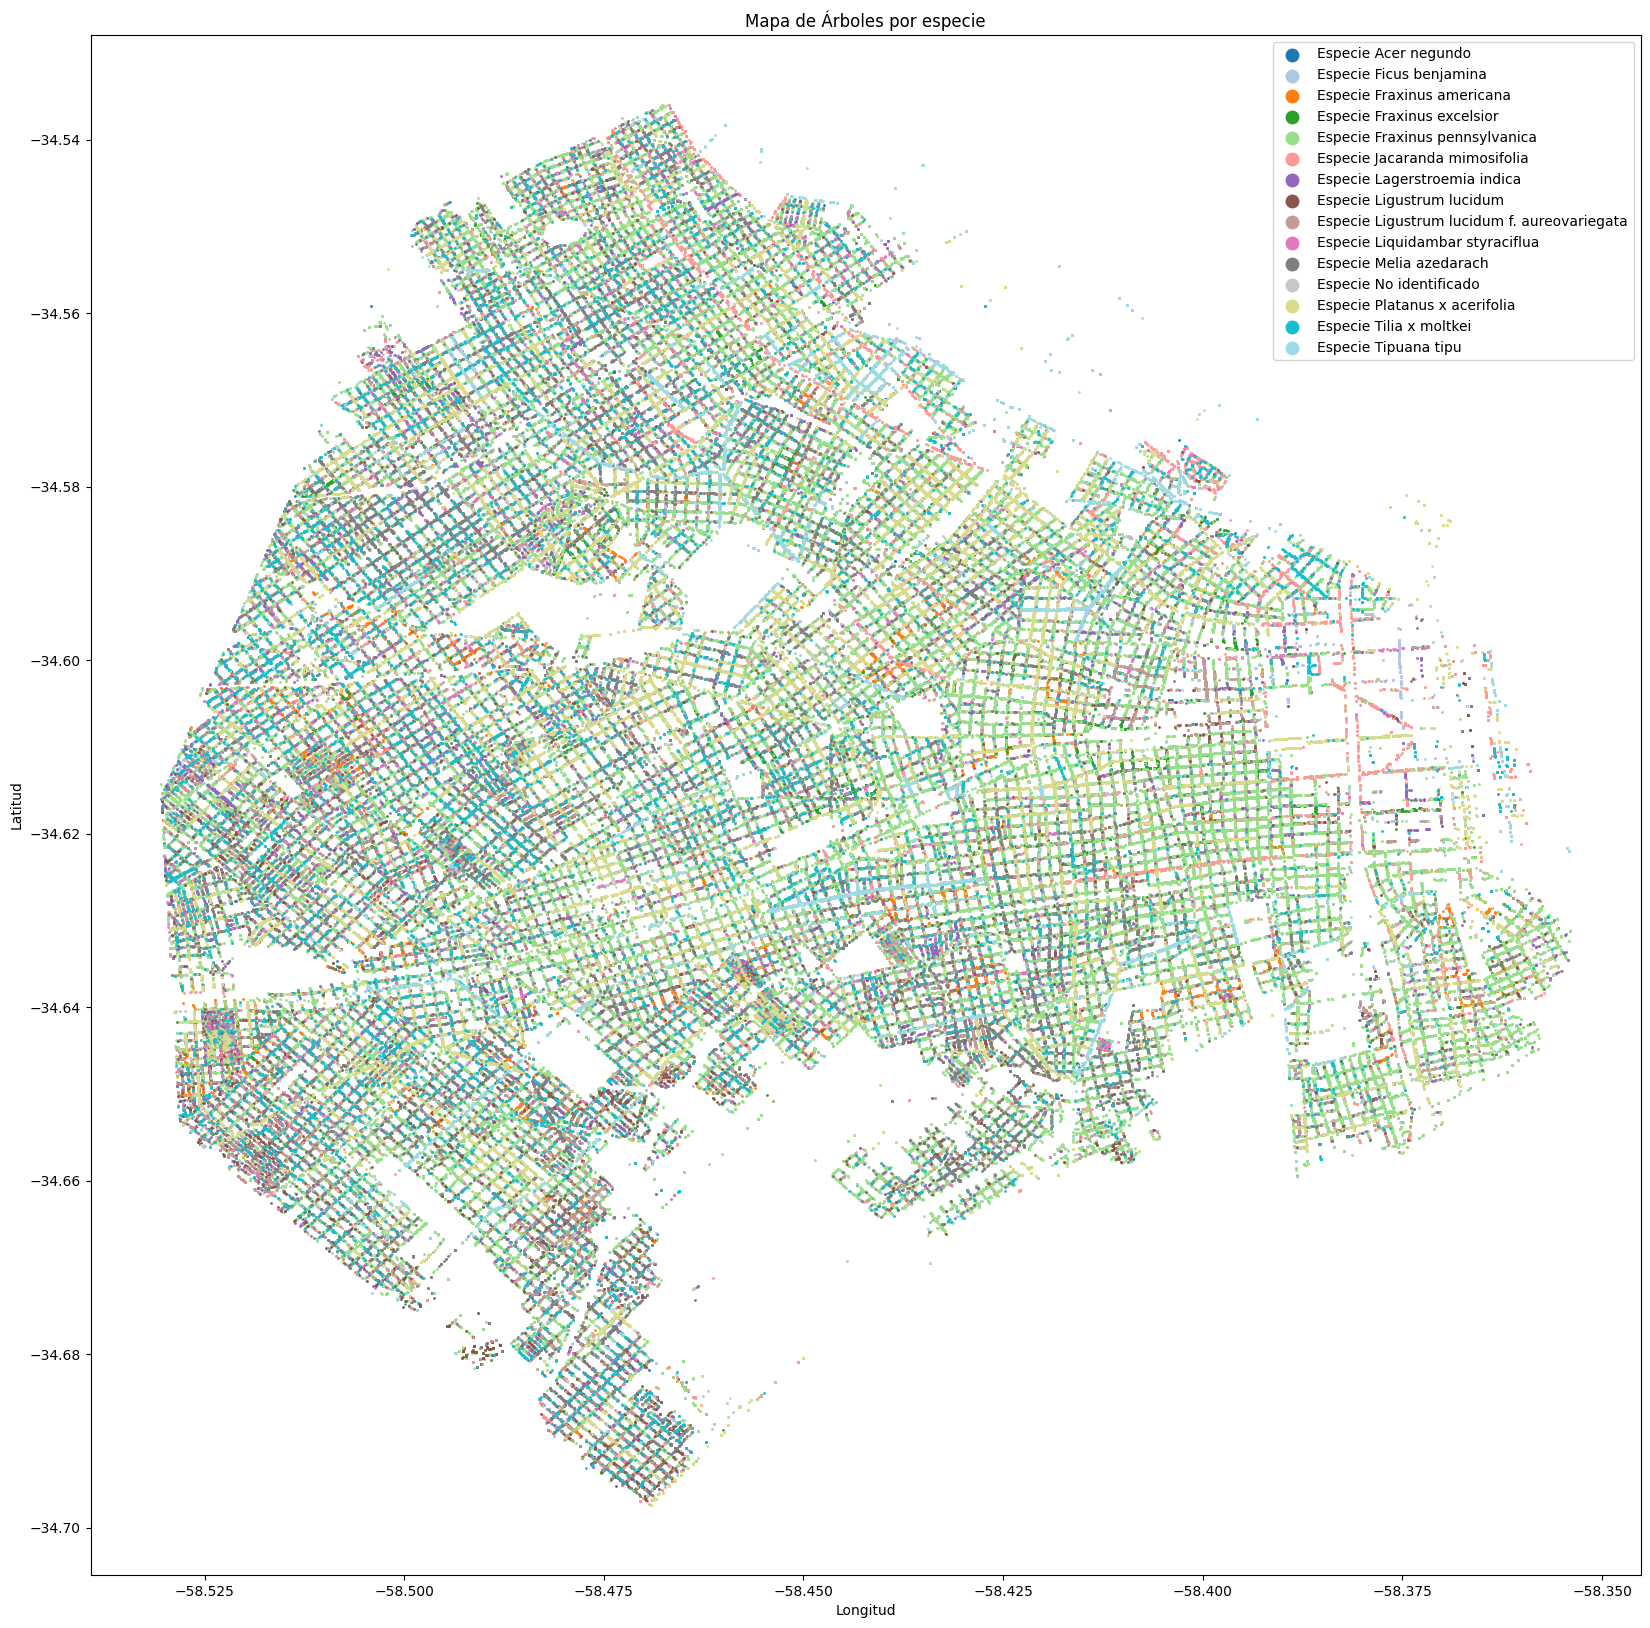

In [72]:


plt.figure(figsize=(20, 20))
categorias = sorted(top10.index)
colores = plt.cm.get_cmap('tab20', len(categorias))

for i, especie in enumerate(categorias):
    subset = datos_arbolado[datos_arbolado['nombre_cientifico'] == especie]
    plt.scatter(
        subset['long'],
        subset['lat'],
        s=1,
        color=colores(i),
        label=f'Especie {(especie)}'
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles por especie")
plt.legend(markerscale=9)
plt.show()

## Ancho_acera

In [73]:
datos_arbolado['ancho_acera'].value_counts()



##plt.boxplot(datos_arbolado['ancho_acera'].notna())

ancho_acera
4.4     94936
3.2     74143
2.8     24276
3       18673
4       14768
        ...  
0.4         1
2.23        1
1.53        1
1.01        1
5.85        1
Name: count, Length: 431, dtype: int64

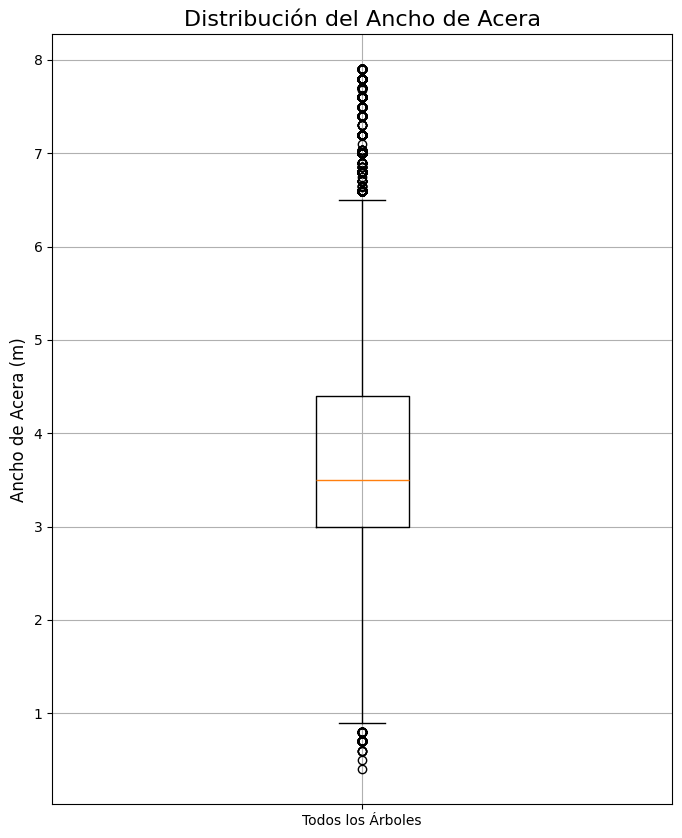

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.DataFrame()
datos_arbolado['ancho_acera_limpio'] = datos_arbolado['ancho_acera'].astype(str).str.replace(',', '.')

# Convertimos a numérico. 
# errors='coerce' transforma valores como 'Sin acera' en NaN (Not a Number)
datos_arbolado['ancho_acera_limpio'] = pd.to_numeric(datos_arbolado['ancho_acera_limpio'], errors='coerce')

# Filtramos valores extremos para que el box plot sea legible
# (Ej: aceras de más de 10 metros)
df_filtrado = datos_arbolado[datos_arbolado['ancho_acera_limpio'] < 8]

# --- 2. CREACIÓN DEL GRÁFICO ---
fig, ax = plt.subplots(figsize=(8, 10))

# Usamos la columna limpia y .dropna() para eliminar los NaN
ax.boxplot(df_filtrado['ancho_acera_limpio'].dropna())

# --- 3. CONFIGURACIÓN DEL GRÁFICO ---
ax.set_title('Distribución del Ancho de Acera', fontsize=16)
ax.set_ylabel('Ancho de Acera (m)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles'])
ax.grid(True)

plt.show()

In [75]:
datos_arbolado[datos_arbolado['ancho_acera_limpio']>7]

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio
43,-58.382926,-34.593509,1,NaN,Cerrito,1200.0,1250.0,Fraxinus pennsylvanica,10.8,Ocupada,Fuera de línea,A nivel,45.0,11.0,10.8
44,-58.382920,-34.593640,1,NaN,Cerrito,1200.0,1248.0,Fraxinus pennsylvanica,10,Ocupada,Fuera de línea,A nivel,30.0,10.0,10.0
45,-58.382920,-34.593640,1,NaN,Cerrito,1200.0,1248.0,Ficus elastica,10,Ocupada,Regular,A nivel,2.0,20.0,10.0
46,-58.382916,-34.593718,1,NaN,Cerrito,1200.0,1240.0,Fraxinus pennsylvanica,10,Ocupada,Fuera de línea,A nivel,50.0,12.0,10.0
122,-58.380768,-34.606540,1,NaN,Pellegrini Carlos,100.0,163.0,Jacaranda mimosifolia,8,Ocupada,Regular,Bajo nivel,40.0,10.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368859,-58.474172,-34.590046,15,153,Chorroarín Av.,600.0,NaN,Melia azedarach,8,Ocupada,Regular,A nivel,58.0,10.0,8.0
368860,NaN,NaN,15,197,De Los Incas Av.,4600.0,430,Fraxinus pennsylvanica,8,Ocupada,Regular,A nivel,25.0,9.0,8.0
369062,NaN,NaN,15,15,Giribone,4300.0,4331.0,Platanus x acerifolia,8,Ocupada,Regular,A nivel,1.0,NaN,8.0
369425,NaN,NaN,15,528,Casafoust,2000.0,2056.0,Lagerstroemia indica,7.4,Ocupada,Regular,Elevada,13.0,4.0,7.4


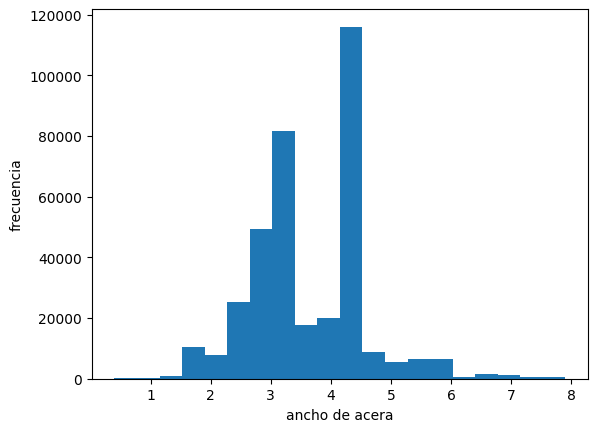

In [76]:
bins=20

plt.hist(df_filtrado['ancho_acera_limpio'], bins=bins)
plt.xlabel('ancho de acera')
plt.ylabel('frecuencia')
plt.show()

## Estado_plantera

In [77]:
datos_arbolado['estado_plantera']= datos_arbolado['estado_plantera'].str.lower()

In [78]:



dic= {
    'vacía': 0,
    'subocupada':1,
    'ocupada': 2,
    'sobreocupada': 3
}
datos_arbolado['estado_plantera']=datos_arbolado['estado_plantera'].map(dic)
cantidad= datos_arbolado['estado_plantera'].value_counts()
clase_plantera= datos_arbolado['estado_plantera']


In [79]:

print(datos_arbolado['estado_plantera'].value_counts())
print(datos_arbolado['estado_plantera'].isna().sum())

estado_plantera
2.0    330898
3.0     38549
1.0       532
0.0         4
Name: count, dtype: int64
197


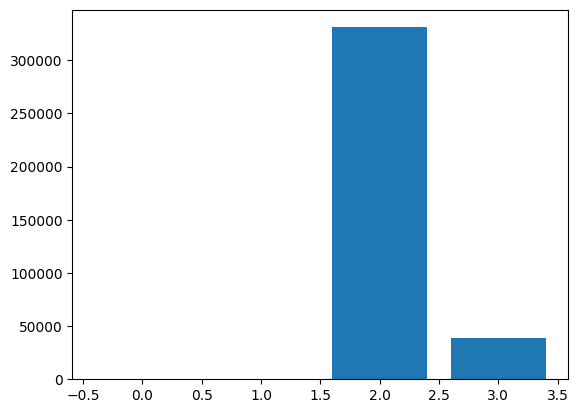

In [80]:
plt.bar(datos_arbolado['estado_plantera'].value_counts().index,datos_arbolado['estado_plantera'].value_counts().values)
plt.show()

## Ubicacion_plantera


In [81]:

datos_arbolado['ubicacion_plantera']=datos_arbolado['ubicacion_plantera'].str.lower()
datos_arbolado['ubicacion_plantera'].value_counts()

mapeo_limpieza = {
    'regular': 'Regular',
    'ochava': 'Ochava',
    'o': 'Ochava',
    'och': 'Ochava',       
    'ochva': 'Ochava',    
    'fuera de línea': 'Fuera de linea'
}
print(datos_arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
regular                   340633
ochava                     21889
fuera de línea              5941
regular                      198
ocupada                       40
fuera nivel                   36
o                             13
cantero grande                13
ochava/fuera línea             3
sobreocupada                   2
och                            2
elevada                        1
fuera línea,ochava             1
subocupada                     1
ochva                          1
fuera de línea, ochava         1
fuera línea/ochava             1
Name: count, dtype: int64


In [82]:


datos_arbolado['ubicacion_plantera']= datos_arbolado['ubicacion_plantera'].map(mapeo_limpieza)
print(datos_arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
Regular           340633
Ochava             21905
Fuera de linea      5941
Name: count, dtype: int64


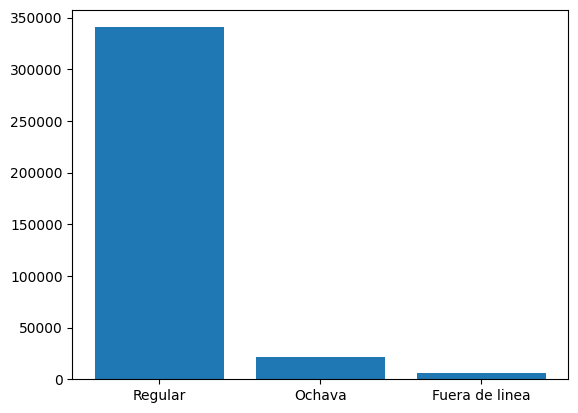

In [83]:
plt.bar(datos_arbolado['ubicacion_plantera'].value_counts().index, datos_arbolado['ubicacion_plantera'].value_counts().values)
plt.show()

## Nivel_plantera

In [84]:
datos_arbolado['nivel_plantera'].value_counts()

nivel_plantera
A nivel                            232099
Elevada                             78433
Bajo nivel                          35653
A Nivel                             21479
Bajo Nivel                            850
AN                                     88
A nivel                                61
a Nivel                                40
A  Nivel                               32
EL                                     21
Elevadas                               18
BN                                     12
Bajo Bivel                              9
Elevado                                 6
Eleveda                                 5
Reducida                                5
elevada                                 4
el                                      2
ELEVADA                                 2
bajo nivel                              2
Baja Nivel                              2
obs: no tiene plantera definida         1
Regular                                 1
Bajo  nivel        

In [85]:
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].str.lower().str.strip()
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
a nivel                            253679
elevada                             78439
bajo nivel                          36505
an                                     89
a  nivel                               32
el                                     23
elevadas                               18
bn                                     12
bajo bivel                              9
elevado                                 6
reducida                                5
eleveda                                 5
baja nivel                              2
regular                                 1
obs: no tiene plantera definida         1
ochava                                  1
bajo  nivel                             1
Name: count, dtype: int64


In [86]:


mapeo_ordinal = {
    # Nivel 0: Bajo Nivel
    'bajo nivel': 0,
    'bajo bivel': 0,
    'baja nivel': 0,
    'bajo  nivel': 0,
    'bn': 0,

    # Nivel 1: A Nivel (el estándar)
    'a nivel': 1,
    'a  nivel': 1,
    'an': 1,
    'a nvel': 1, # (Asumimos posibles typos)
    
    # Nivel 2: Elevada
    'elevada': 2,
    'elevado': 2,
    'elevadas': 2,
    'eleveda': 2,
    'el': 2,
    'elevada': 2
}
datos_arbolado['nivel_plantera']= datos_arbolado['nivel_plantera'].map(mapeo_ordinal)
print(datos_arbolado['nivel_plantera'].value_counts())

nivel_plantera
1.0    253800
2.0     78491
0.0     36529
Name: count, dtype: int64


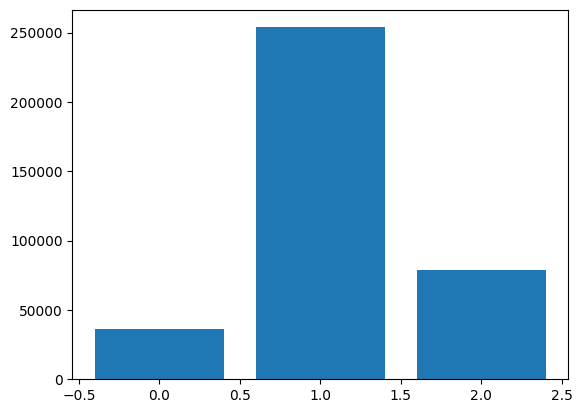

In [87]:
plt.bar(datos_arbolado['nivel_plantera'].value_counts().index, datos_arbolado['nivel_plantera'].value_counts().values)
plt.show()

## Diametro_altura_pecho

In [88]:
filtro= datos_arbolado['diametro_altura_pecho']>100
print(datos_arbolado[filtro])

             long        lat  comuna manzana                   calle_nombre  \
18     -58.381515 -34.591950       1     NaN              Pellegrini Carlos   
355    -58.377803 -34.607534       1     NaN                      Esmeralda   
434    -58.367924 -34.611661       1     NaN                       Azopardo   
437    -58.367924 -34.611661       1     NaN                       Azopardo   
951    -58.391664 -34.603186       1     NaN                        Lavalle   
...           ...        ...     ...     ...                            ...   
369679        NaN        NaN      15     365  Solano López Francisco  Mcal.   
369699        NaN        NaN      15      12                 Ballivián José   
369792        NaN        NaN      15     874                     Elcano Av.   
369809        NaN        NaN      15     370  Solano López Francisco  Mcal.   
369885        NaN        NaN      15     756        Justo Juan Bautista Av.   

       calle_altura calle_chapa       nombre_cienti

In [89]:
datos_arbolado['diametro_altura_pecho'].describe()

count    369894.000000
mean         31.986864
std          21.267623
min           0.000000
25%          17.000000
50%          29.000000
75%          43.000000
max         199.000000
Name: diametro_altura_pecho, dtype: float64

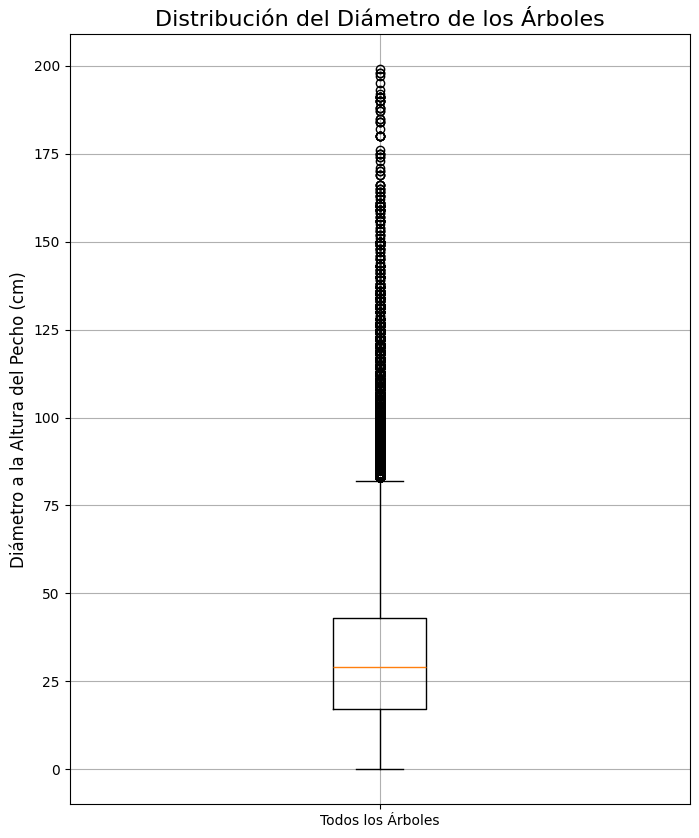

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que ya tenés el DataFrame limpio y cargado como 'df_clean'
# df_clean = ...

# Filtramos valores extremos para que el gráfico sea legible
df_filtrado = datos_arbolado[datos_arbolado['diametro_altura_pecho'] < 200]

# Preparamos la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 10))

# La función boxplot de matplotlib recibe directamente la serie de datos
# Es importante usar .dropna() para eliminar valores nulos que pueden dar error
ax.boxplot(df_filtrado['diametro_altura_pecho'].dropna())

# Configuramos el gráfico
ax.set_title('Distribución del Diámetro de los Árboles', fontsize=16)
ax.set_ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
ax.set_xticklabels(['Todos los Árboles']) # Le ponemos nombre al eje X
ax.grid(True) # Añadimos una grilla

plt.show()

## Altura_arbol

In [91]:
datos_arbolado['altura_arbol'].value_counts()

altura_arbol
8.0     35071
9.0     34295
7.0     32517
10.0    30200
6.0     27123
12.0    23912
4.0     23125
3.0     22582
5.0     22244
2.0     21921
11.0    20994
13.0    15027
14.0    12205
15.0    10955
16.0     7484
17.0     4911
18.0     4911
20.0     3357
19.0     2675
22.0     2063
21.0     1740
24.0     1346
25.0     1321
23.0     1266
26.0      611
27.0      600
28.0      460
30.0      308
29.0      205
32.0       99
31.0       91
33.0       44
35.0       41
36.0       40
40.0       36
34.0       35
38.0       24
39.0       11
37.0        6
1.0         2
Name: count, dtype: int64

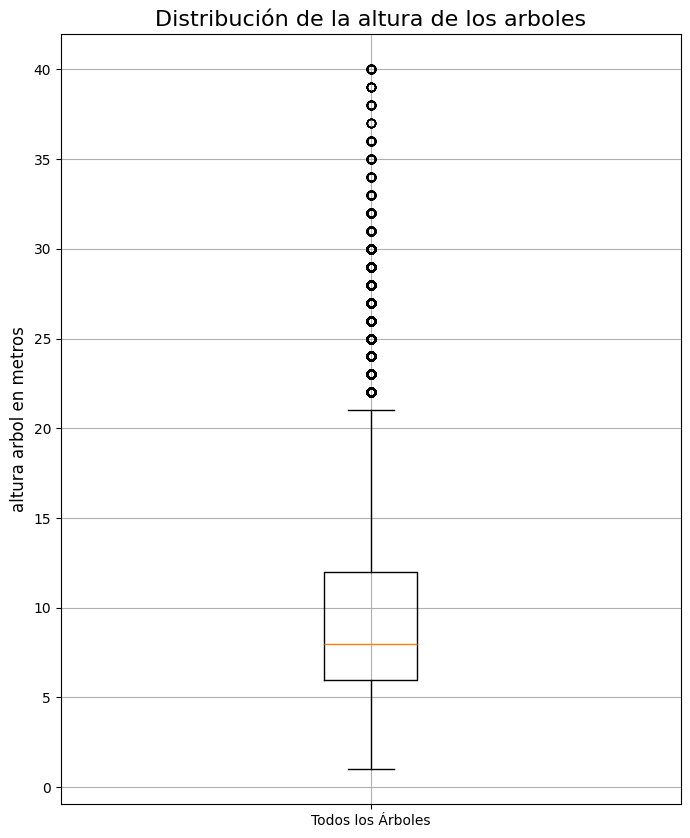

In [92]:
# Preparamos la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 10))


# La función boxplot de matplotlib recibe directamente la serie de datos
# Es importante usar .dropna() para eliminar valores nulos que pueden dar error
ax.boxplot(datos_arbolado['altura_arbol'].dropna())

# Configuramos el gráfico
ax.set_title('Distribución de la altura de los arboles', fontsize=16)
ax.set_ylabel('altura arbol en metros', fontsize=12)
ax.set_xticklabels(['Todos los Árboles']) # Le ponemos nombre al eje X
ax.grid(True) # Añadimos una grilla

plt.show()

In [93]:
datos_arbolado.to_pickle('../data/datos_arbolado')

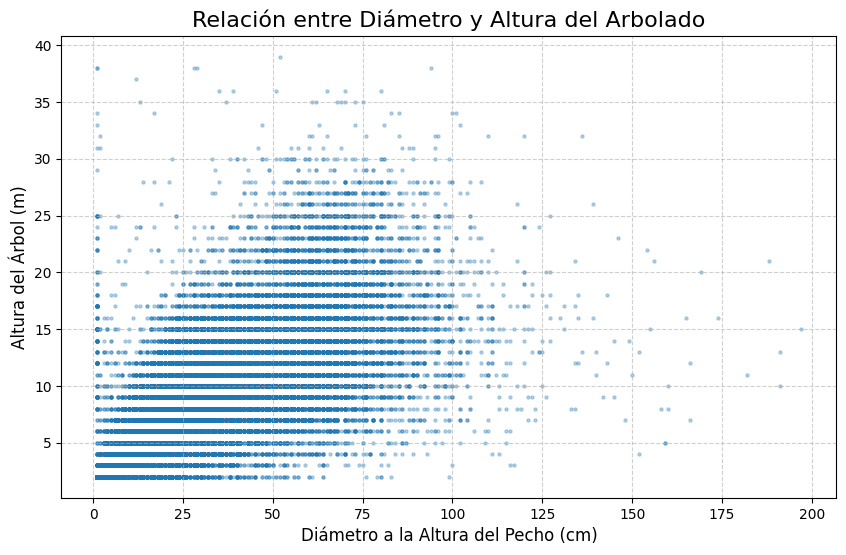

----------------------------------------
Resultados de Correlación (sobre 361865 árboles):
  Correlación de Pearson (r): 0.6647
 Correlación de Spearman (ρ): 0.7093
----------------------------------------


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que tu DataFrame se llama 'datos_arbolado'
# ---- 1. Limpieza y Preparación ----

# Creamos una copia para no modificar el original
df_plot = datos_arbolado.copy()

# (Paso de seguridad) Aseguramos que ambas columnas sean numéricas
# 'coerce' convertirá cualquier texto (como 'Sin dato') en NaN
df_plot['diametro_altura_pecho'] = pd.to_numeric(df_plot['diametro_altura_pecho'], errors='coerce')
df_plot['altura_arbol'] = pd.to_numeric(df_plot['altura_arbol'], errors='coerce')

# Eliminamos filas donde falte alguno de estos dos datos
df_plot.dropna(subset=['diametro_altura_pecho', 'altura_arbol'], inplace=True)

# ---- 2. Filtrado de Outliers ----
# Filtramos valores extremos que "aplastarían" el gráfico
# Ej: Diámetros > 200cm o Alturas > 40m
df_filtrado = df_plot[
    (df_plot['diametro_altura_pecho'] > 0) & (df_plot['diametro_altura_pecho'] < 200) &
    (df_plot['altura_arbol'] > 0) & (df_plot['altura_arbol'] < 40)
]

# ---- 3. Muestreo (Sampling) ----
# Tomamos una muestra aleatoria de 50,000 puntos para evitar el overplotting
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ---- 4. Creación del Gráfico ----
plt.figure(figsize=(10, 6))
plt.scatter(
    df_sample['diametro_altura_pecho'],
    df_sample['altura_arbol'],
    alpha=0.3,  # Transparencia para ver la densidad
    s=5         # Tamaño pequeño del punto
)

plt.title('Relación entre Diámetro y Altura del Arbolado', fontsize=16)
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Altura del Árbol (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# ---- 3. Muestreo (Sampling) ----
# ... (tu código de muestreo para el gráfico) ...
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ==========================================================
# AÑADIR AQUÍ EL CÁLCULO DE CORRELACIÓN
# ==========================================================
# Usamos df_filtrado (todos los datos limpios) para el cálculo estadístico

# --- Método 1: Correlación de Pearson (la más común) ---
# Mide la relación LINEAL
corr_pearson = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='pearson'
)

# --- Método 2: Correlación de Spearman ---
# Mide la relación MONOTÓNICA (si una sube, la otra también, 
# aunque no sea una línea recta). Es útil si la relación se "aplana".
corr_spearman = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='spearman'
)

print("-" * 40)
print(f"Resultados de Correlación (sobre {len(df_filtrado)} árboles):")
print(f"  Correlación de Pearson (r): {corr_pearson:.4f}")
print(f" Correlación de Spearman (ρ): {corr_spearman:.4f}")
print("-" * 40)
# ==========================================================

# ---- 4. Creación del Gráfico ----
# (Tu código de plt.scatter() sigue aquí, usando df_sample)
plt.figure(figsize=(10, 6))
# ... (el resto de tu código de plotting) ...

## Relacion ancho acera con estado plantera sobreocupada

In [97]:
datos_arbolado.to_pickle('../data/datos_arbolado')